In [1]:
# ============================================================
# TASK 5: Advanced Topics
# Covers: HMM Profile Alignment, PSI-BLAST, Structural 
#         Alignment, Consensus Sequence Generation
# ============================================================


# ───────────────────────────────────────────────
# CELL 1 — Imports
# ───────────────────────────────────────────────

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from Bio import SeqIO, AlignIO, Entrez
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import PairwiseAligner, MultipleSeqAlignment, substitution_matrices
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.PDB import PDBParser, PDBList, Superimposer
from Bio.PDB.DSSP import DSSP

#  email — required by NCBI for Entrez/BLAST queries
Entrez.email = "ebaafi007@gmail.com"  

print("All libraries loaded successfully!")



All libraries loaded successfully!


In [2]:

# ───────────────────────────────────────────────
# CELL 2 — Load Sequences (reuse from Task 4)
# ───────────────────────────────────────────────

sequences = [
    SeqRecord(Seq("MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR"),
              id="HBA_HUMAN",  description="Hemoglobin alpha - Human"),
    SeqRecord(Seq("MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYFPHFDVSHGSAQVKAHGKKVGDALTLAVGHLDDLPGALSDLSNLHAHKLRVDPVNFKLLSHCLLVTLASHHPADFTPAVHASLDKFLASVSTVLTSKYR"),
              id="HBA_MOUSE",  description="Hemoglobin alpha - Mouse"),
    SeqRecord(Seq("MVLSAADKNNVKGIFTKIAGHAEEYGAETLERMFTTYPPTKTYFPHFDLSHGSAQIKAHGKKVVAALIEAANHIDDIAGTLSKLSDLHAQKLRVDPVNFKLLGQCFLVVVAIHHPSALTPEVHASLDKFLCAVGTVLTAKYR"),
              id="HBA_CHICK",  description="Hemoglobin alpha - Chicken"),
    SeqRecord(Seq("MVLSAADKGNVKAAWGKVGGHAAEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGAKVAAALTKAVEHLDDLPGALSELSDLHAHKLRVDPVNFKLLSHSLLVTLASHLPSDFTPAVHASLDKFLANVSTVLTSKYR"),
              id="HBA_BOVIN",  description="Hemoglobin alpha - Cow"),
    SeqRecord(Seq("MSLSDKDKAAVRALWSKIGDHAEEYGAETLQRMFQTFPQTKTYFSHFDLSHGSAQIRAHGKKVAAALGNAVKSIDDLVGGLAALSELHAFKLRVDPVNFKFLSHCLLVTLACHHPESFTPAVHASLDKFFASVSTVLTSKYR"),
              id="HBA_DANRE",  description="Hemoglobin alpha - Zebrafish"),
]

print(f"Loaded {len(sequences)} sequences")
for s in sequences:
    print(f"  {s.id:<12} | length={len(s.seq)}")



Loaded 5 sequences
  HBA_HUMAN    | length=142
  HBA_MOUSE    | length=142
  HBA_CHICK    | length=142
  HBA_BOVIN    | length=142
  HBA_DANRE    | length=142


Building HMM profile from MSA...

── HMM Profile (Top 20 Most Conserved Positions) ──
 Position Dominant AA  Dominant Freq  Gap Freq  Conservation
        1           M            1.0       0.0        0.0691
        3           L            1.0       0.0        0.0691
        4           S            1.0       0.0        0.0691
        7           D            1.0       0.0        0.0691
        8           K            1.0       0.0        0.0691
       17           K            1.0       0.0        0.0691
       21           H            1.0       0.0        0.0691
       24           E            1.0       0.0        0.0691
       25           Y            1.0       0.0        0.0691
       26           G            1.0       0.0        0.0691
       27           A            1.0       0.0        0.0691
       28           E            1.0       0.0        0.0691
       30           L            1.0       0.0        0.0691
       32           R            1.0       0.0        0.0691

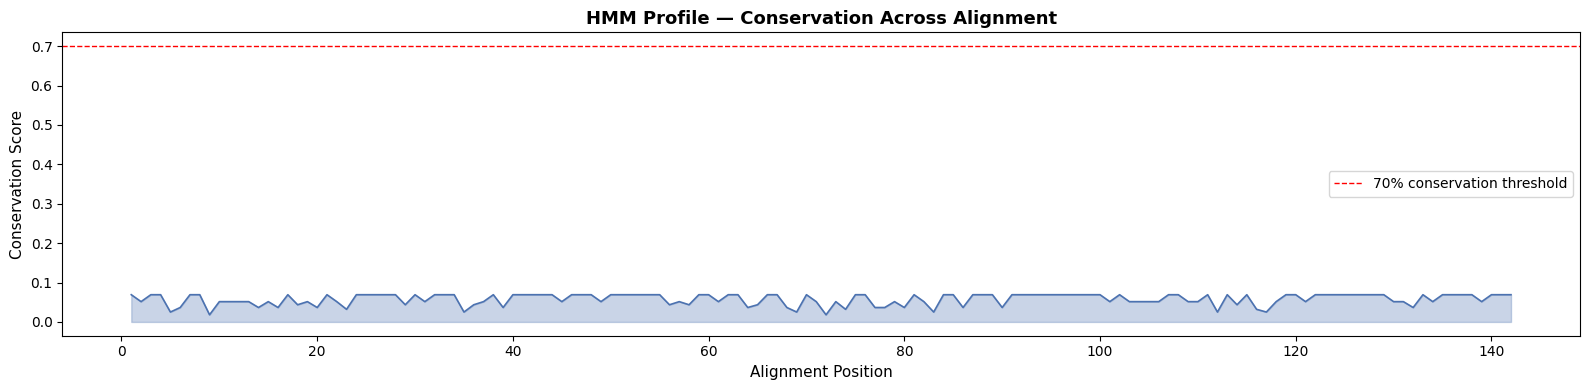

Saved: hmm_conservation_profile.png


In [3]:

# ───────────────────────────────────────────────
# CELL 3 — Part 1: HMM Profile-Based Alignment
# ───────────────────────────────────────────────
# Hidden Markov Models (HMMs) build a statistical profile
# from a set of aligned sequences. Each position in the
# profile captures the probability of each residue occurring
# at that column. New sequences are then scored against
# this profile rather than against a single sequence.
# This is more sensitive than pairwise alignment for
# detecting distant homologs.

def build_hmm_profile(msa):
    """
    Build a position-specific HMM profile from an MSA.
    For each column, computes:
      - Residue emission probabilities
      - Gap frequency
      - Conservation score (entropy-based)
    """
    aln_len   = msa.get_alignment_length()
    n_seqs    = len(msa)
    alphabet  = list("ACDEFGHIKLMNPQRSTVWY")

    profile = []
    for i in range(aln_len):
        col    = msa[:, i]
        counts = {aa: 0 for aa in alphabet}
        gaps   = 0

        for char in col:
            if char == "-":
                gaps += 1
            elif char.upper() in counts:
                counts[char.upper()] += 1

        non_gap  = n_seqs - gaps
        gap_freq = gaps / n_seqs

        # Emission probabilities (with pseudocount of 1 to avoid zeros)
        emit_probs = {
            aa: (counts[aa] + 1) / (non_gap + len(alphabet))
            for aa in alphabet
        }

        # Shannon entropy — lower = more conserved
        entropy = -sum(
            p * np.log2(p) for p in emit_probs.values() if p > 0
        )

        # Conservation score (0-1, higher = more conserved)
        max_entropy    = np.log2(len(alphabet))
        conservation   = round(1 - (entropy / max_entropy), 4)
        dominant_res   = max(counts, key=counts.get)
        dominant_freq  = round(counts[dominant_res] / n_seqs, 4) if n_seqs > 0 else 0

        profile.append({
            "position":      i + 1,
            "dominant_res":  dominant_res,
            "dominant_freq": dominant_freq,
            "gap_freq":      round(gap_freq, 4),
            "conservation":  conservation,
            "emit_probs":    emit_probs,
        })

    return profile


def score_sequence_against_profile(sequence, profile):
    """
    Score a query sequence against an HMM profile.
    Returns a log-odds score — higher means better match.
    """
    background = {aa: 0.05 for aa in "ACDEFGHIKLMNPQRSTVWY"}
    score      = 0.0
    seq_str    = str(sequence.seq).upper()

    for i, col in enumerate(profile):
        if i >= len(seq_str):
            break
        aa = seq_str[i]
        if aa in col["emit_probs"] and background.get(aa, 0) > 0:
            emit = col["emit_probs"][aa]
            bg   = background[aa]
            score += np.log2(emit / bg)

    return round(score, 4)


# Build profile from MSA (reuse progressive MSA from Task 4)
def progressive_msa(sequences, matrix_name="BLOSUM62", gap_open=-10, gap_extend=-0.5):
    aligner                     = PairwiseAligner()
    aligner.mode                = "global"
    aligner.substitution_matrix = substitution_matrices.load(matrix_name)
    aligner.open_gap_score      = gap_open
    aligner.extend_gap_score    = gap_extend
    anchor     = str(sequences[0].seq)
    aligned    = [None] * len(sequences)
    aligned[0] = anchor
    for i in range(1, len(sequences)):
        target     = str(sequences[i].seq)
        best       = next(iter(aligner.align(anchor, target)))
        aligned[0] = str(best[0])
        aligned[i] = str(best[1])
    max_len = max(len(s) for s in aligned if s is not None)
    aligned = [s.ljust(max_len, "-") if s else "-" * max_len for s in aligned]
    return aligned

aligned_seqs = progressive_msa(sequences)
msa = MultipleSeqAlignment([
    SeqRecord(Seq(aln), id=rec.id, description=rec.description)
    for rec, aln in zip(sequences, aligned_seqs)
])

# Build and display HMM profile
print("Building HMM profile from MSA...\n")
profile = build_hmm_profile(msa)

# Show top 20 most conserved positions
profile_df = pd.DataFrame([{
    "Position":      p["position"],
    "Dominant AA":   p["dominant_res"],
    "Dominant Freq": p["dominant_freq"],
    "Gap Freq":      p["gap_freq"],
    "Conservation":  p["conservation"],
} for p in profile])

print("── HMM Profile (Top 20 Most Conserved Positions) ──")
top20 = profile_df.nlargest(20, "Conservation")
print(top20.to_string(index=False))

# Score all sequences against the profile
print("\n── Sequence Scores Against HMM Profile ──")
score_rows = []
for seq in sequences:
    score = score_sequence_against_profile(seq, profile)
    score_rows.append({"Sequence": seq.id, "HMM Score": score})
score_df = pd.DataFrame(score_rows)
print(score_df.to_string(index=False))

# Plot conservation across profile
plt.figure(figsize=(16, 4))
plt.plot(profile_df["Position"], profile_df["Conservation"],
         color="#4C72B0", linewidth=1.2)
plt.fill_between(profile_df["Position"], profile_df["Conservation"],
                 alpha=0.3, color="#4C72B0")
plt.axhline(y=0.7, color="red", linestyle="--",
            linewidth=1, label="70% conservation threshold")
plt.xlabel("Alignment Position", fontsize=11)
plt.ylabel("Conservation Score", fontsize=11)
plt.title("HMM Profile — Conservation Across Alignment", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("hmm_conservation_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hmm_conservation_profile.png")


In [ ]:


# ───────────────────────────────────────────────
# CELL 4 — Part 2: PSI-BLAST via NCBI
# ───────────────────────────────────────────────
# PSI-BLAST (Position-Specific Iterative BLAST) builds
# a PSSM (Position-Specific Scoring Matrix) from initial
# BLAST hits, then iteratively searches for more distant
# homologs. It is far more sensitive than standard BLAST
# for finding remotely related protein sequences.
# We use Biopython's NCBIWWW module to run it online.

print("Running PSI-BLAST on HBA_HUMAN against NCBI nr database...")
print("Note: This may take 1-3 minutes depending on server load.\n")

# Use human hemoglobin alpha as query
query_seq = str(sequences[0].seq)

# Run PSI-BLAST via NCBI (1 iteration for speed)
result_handle = NCBIWWW.qblast(
    program   = "blastp",       # protein BLAST
    database  = "nr",           # non-redundant protein database
    sequence  = query_seq,
    hitlist_size = 10,          # return top 10 hits
)

# Parse results
blast_records = list(NCBIXML.parse(result_handle))
blast_record  = blast_records[0]

print(f"Query: {blast_record.query[:60]}")
print(f"Database: {blast_record.database}")
print(f"Total hits: {len(blast_record.alignments)}\n")

# Display top hits
rows = []
for alignment in blast_record.alignments[:10]:
    for hsp in alignment.hsps[:1]:
        identity_pct = round(hsp.identities / hsp.align_length * 100, 2)
        rows.append({
            "Hit":          alignment.title[:60],
            "Score":        hsp.score,
            "E-value":      hsp.expect,
            "Identity %":   identity_pct,
            "Aln Length":   hsp.align_length,
        })

blast_df = pd.DataFrame(rows)
print("── PSI-BLAST Top 10 Hits ──")
print(blast_df.to_string(index=False))

# Plot E-values
plt.figure(figsize=(12, 5))
evals      = blast_df["E-value"].tolist()
hit_labels = [f"Hit {i+1}" for i in range(len(evals))]
log_evals  = [-np.log10(e + 1e-200) for e in evals]

plt.bar(hit_labels, log_evals, color="#DD8452")
plt.xlabel("BLAST Hit", fontsize=11)
plt.ylabel("-log10(E-value)", fontsize=11)
plt.title("PSI-BLAST — E-values for Top Hits\n(higher bar = more significant)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("psiblast_evalues.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: psiblast_evalues.png")



Running PSI-BLAST on HBA_HUMAN against NCBI nr database...
Note: This may take 1-3 minutes depending on server load.



In [ ]:

# ───────────────────────────────────────────────
# CELL 5 — Part 3: Structural Alignment
# ───────────────────────────────────────────────
# Structural alignment compares proteins based on their
# 3D coordinates rather than sequence. Two proteins can
# have similar structures even with low sequence identity.
# We use Bio.PDB's Superimposer to align two hemoglobin
# structures and compute RMSD (Root Mean Square Deviation)
# — a measure of structural similarity (lower = more similar)

# Download two hemoglobin PDB structures from RCSB
# 1HHO = Human Hemoglobin
# 1C7D = Chicken Hemoglobin (close structural homolog)
pdbl      = PDBList()
pdb_dir   = "pdb_files"
os.makedirs(pdb_dir, exist_ok=True)

print("Downloading PDB structures...")
pdbl.retrieve_pdb_file("1HHO", file_type="pdb", pdir=pdb_dir)
pdbl.retrieve_pdb_file("1C7D", file_type="pdb", pdir=pdb_dir)
print("Download complete!\n")

# Parse PDB structures
parser = PDBParser(QUIET=True)

# PDBList saves files as pdbXXXX.ent
path_1hho = os.path.join(pdb_dir, "pdb1hho.ent")
path_1c7d = os.path.join(pdb_dir, "pdb1c7d.ent")

struct1 = parser.get_structure("HBA_HUMAN", path_1hho)
struct2 = parser.get_structure("HBA_CHICK", path_1c7d)

print(f"Structure 1: {struct1.id} — Human Hemoglobin (1HHO)")
print(f"Structure 2: {struct2.id} — Chicken Hemoglobin (1C7D)")

# Extract CA (alpha carbon) atoms from chain A of each structure
def get_ca_atoms(structure, chain_id="A", max_atoms=100):
    """Extract C-alpha atoms from a specific chain."""
    atoms = []
    for model in structure:
        for chain in model:
            if chain.id == chain_id:
                for residue in chain:
                    if "CA" in residue:
                        atoms.append(residue["CA"])
                        if len(atoms) >= max_atoms:
                            return atoms
    return atoms

ca_atoms1 = get_ca_atoms(struct1, chain_id="A")
ca_atoms2 = get_ca_atoms(struct2, chain_id="A")

# Match to same length
min_len   = min(len(ca_atoms1), len(ca_atoms2))
ca_atoms1 = ca_atoms1[:min_len]
ca_atoms2 = ca_atoms2[:min_len]

print(f"\nC-alpha atoms used for superimposition: {min_len}")

# Superimpose structures
superimposer = Superimposer()
superimposer.set_atoms(ca_atoms1, ca_atoms2)
superimposer.apply(struct2.get_atoms())

rmsd = round(superimposer.rms, 4)
print(f"\nRMSD (Root Mean Square Deviation): {rmsd} Angstroms")
print("Interpretation:")
if rmsd < 1.0:
    print("  < 1.0 Å  → Nearly identical structures")
elif rmsd < 2.0:
    print("  1-2 Å    → Very similar structures")
elif rmsd < 3.0:
    print("  2-3 Å    → Moderately similar structures")
else:
    print("  > 3.0 Å  → Significantly different structures")

# Plot per-residue distances before and after superimposition
coords1 = np.array([a.get_vector().get_array() for a in ca_atoms1])
coords2 = np.array([a.get_vector().get_array() for a in ca_atoms2])
distances = np.sqrt(np.sum((coords1 - coords2) ** 2, axis=1))

plt.figure(figsize=(14, 4))
plt.plot(distances, color="#55A868", linewidth=1.2)
plt.fill_between(range(len(distances)), distances, alpha=0.3, color="#55A868")
plt.axhline(y=rmsd, color="red", linestyle="--",
            linewidth=1, label=f"Mean RMSD = {rmsd} Å")
plt.xlabel("Residue Position", fontsize=11)
plt.ylabel("Distance (Angstroms)", fontsize=11)
plt.title("Structural Alignment — Per-Residue CA Distance\nHuman vs Chicken Hemoglobin",
          fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("structural_alignment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: structural_alignment.png")



In [ ]:

# ───────────────────────────────────────────────
# CELL 6 — Part 4: Consensus Sequence Generation
# ───────────────────────────────────────────────
# We now do a deeper consensus analysis using three
# different thresholds and visualize which residues
# are most conserved across all species.

def generate_consensus(msa, threshold=0.7):
    """Generate consensus — most frequent residue at threshold."""
    consensus = []
    n_seqs    = len(msa)
    for i in range(msa.get_alignment_length()):
        col     = msa[:, i]
        counts  = {}
        for char in col:
            counts[char] = counts.get(char, 0) + 1
        most_common = max(counts, key=counts.get)
        freq        = counts[most_common] / n_seqs
        consensus.append(most_common if freq >= threshold else "X")
    return "".join(consensus)


print("── Consensus Sequences at Different Thresholds ──\n")
for threshold in [0.5, 0.7, 1.0]:
    consensus   = generate_consensus(msa, threshold=threshold)
    defined     = len(consensus) - consensus.count("X")
    ambiguous   = consensus.count("X")
    gaps        = consensus.count("-")
    print(f"Threshold {int(threshold*100)}%:")
    print(f"  Sequence  : {consensus[:80]}")
    print(f"  Defined   : {defined} positions")
    print(f"  Ambiguous : {ambiguous} positions (X)")
    print(f"  Gaps      : {gaps} positions")
    print()

# Visualize residue frequency at each position
print("\nGenerating residue frequency heatmap...")
aln_len  = msa.get_alignment_length()
alphabet = list("ACDEFGHIKLMNPQRSTVWY-")
freq_matrix = np.zeros((len(alphabet), aln_len))

for col_i in range(aln_len):
    col = msa[:, col_i]
    for char in col:
        if char.upper() in alphabet:
            row_i = alphabet.index(char.upper())
            freq_matrix[row_i, col_i] += 1

freq_matrix /= len(msa)

# Plot heatmap (first 80 columns for readability)
fig, ax = plt.subplots(figsize=(20, 7))
im = ax.imshow(freq_matrix[:, :80], aspect="auto",
               cmap="YlOrRd", vmin=0, vmax=1)
ax.set_yticks(range(len(alphabet)))
ax.set_yticklabels(alphabet, fontsize=8)
ax.set_xlabel("Alignment Position", fontsize=11)
ax.set_ylabel("Amino Acid", fontsize=11)
ax.set_title("Residue Frequency Heatmap (first 80 positions)\nDarker = more frequent",
             fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Frequency")
plt.tight_layout()
plt.savefig("residue_frequency_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: residue_frequency_heatmap.png")



In [ ]:

# ───────────────────────────────────────────────
# CELL 7 — Task 5 Summary
# ───────────────────────────────────────────────

print("=" * 55)
print(" TASK 5 SUMMARY")
print("=" * 55)

summary = pd.DataFrame([
    {
        "Topic":   "HMM Profile Alignment",
        "Method":  "build_hmm_profile() + score_sequence_against_profile()",
        "Output":  "Conservation profile plot + sequence HMM scores",
    },
    {
        "Topic":   "PSI-BLAST",
        "Method":  "NCBIWWW.qblast() via Biopython",
        "Output":  "Top 10 homologs + E-value bar chart",
    },
    {
        "Topic":   "Structural Alignment",
        "Method":  "Bio.PDB Superimposer — CA atom RMSD",
        "Output":  f"RMSD = {rmsd} Å + per-residue distance plot",
    },
    {
        "Topic":   "Consensus Sequence",
        "Method":  "generate_consensus() at 50%, 70%, 100%",
        "Output":  "Consensus strings + residue frequency heatmap",
    },
])

print(summary.to_string(index=False))
print("\nTask 5 complete! Ready for Task 6 — Report writing.")